# EDA — NPS Swift

Notebook de exploração usando as duas bases recebidas:

- **NPS.xlsx**: avaliações NPS, comentários, loja e flag da loja.
- **TRANS.xlsx**: volume mensal de transações por loja, região, município e UF.



In [1]:
from pathlib import Path
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True




# Diretórios padronizados do projeto
# Se o notebook for executado dentro da pasta eda/, usamos a pasta pai como raiz.
def encontrar_raiz_projeto():
    cwd = Path.cwd()
    candidatos = [cwd, cwd.parent]
    for candidato in candidatos:
        nomes = {p.name.lower() for p in candidato.iterdir()} if candidato.exists() else set()
        if 'readme.md' in nomes or 'readme' in nomes or 'eda' in nomes or '.git' in nomes:
            return candidato
    return cwd

PROJECT_ROOT = encontrar_raiz_projeto()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def achar_arquivo(nome):
    candidatos = [
        RAW_DIR / nome,
        PROJECT_ROOT / nome,
        Path.cwd() / nome,
    ]

    for caminho in candidatos:
        if caminho.exists():
            return caminho

    caminhos_testados = '\n'.join(str(c) for c in candidatos)
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. '\
        f'Coloque o arquivo em {RAW_DIR} com o nome padronizado.\n\n'\
        f'Caminhos testados:\n{caminhos_testados}'
    )


NPS_PATH = achar_arquivo('NPS.xlsx')
TRANS_PATH = achar_arquivo('TRANS.xlsx')

print('Raiz do projeto:', PROJECT_ROOT)
print('Pasta raw:', RAW_DIR)
print('Pasta processed:', PROCESSED_DIR)
print('Base NPS:', NPS_PATH)
print('Base Transações:', TRANS_PATH)


Raiz do projeto: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift
Pasta raw: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift\data\raw
Pasta processed: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift\data\processed
Base NPS: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift\data\raw\NPS.xlsx
Base Transações: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift\data\raw\TRANS.xlsx


## 1. Leitura das bases e padronização mínima

A base de NPS vem em nível de avaliação/comentário, mas algumas linhas sem comentário aparecem agregadas em `qtd_clientes`. Por isso, quando a pergunta é sobre distribuição geral de NPS, uso `qtd_clientes` como peso. Quando a pergunta é sobre texto, filtro apenas comentários reais.

In [2]:
nps_raw = pd.read_excel(NPS_PATH)
trans_raw = pd.read_excel(TRANS_PATH)

print('NPS bruto:', nps_raw.shape)
print('Transações bruto:', trans_raw.shape)

display(nps_raw.head(3))
display(trans_raw.head(3))

NPS bruto: (240352, 7)
Transações bruto: (3645, 6)


,Mes Ano,classificacao,Data Avaliação,CentroNv2,qtd_clientes,Comentario,Flag
0,2025-01-01,promotor,2025-01-01 00:00:00,L5001-RIBEIRAO PRETO (0217),6,-,REGULAR
1,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,REGULAR
2,2025-01-01,neutro,2025-01-02 00:00:00,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",REGULAR


,CentroNv2,Mes Ano,Regiao_IM,Municipio,UF,Transações
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,Interior,RIBEIRÃO PRETO,SP,9738
1,L5002-ALPHAVILLE (0290),2025-01-01,RMSP,BARUERI,SP,7890
2,L5003-LINS (0340),2025-01-01,Interior,LINS,SP,7111


In [3]:
def normalizar_colunas(df):
    mapa = {}
    for col in df.columns:
        c = str(col).strip()
        c = unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode('utf-8')
        c = c.lower().replace(' ', '_').replace('-', '_')
        c = re.sub(r'[^a-z0-9_]+', '', c)
        c = re.sub(r'_+', '_', c).strip('_')
        mapa[col] = c
    return df.rename(columns=mapa)

nps = normalizar_colunas(nps_raw).copy()
trans = normalizar_colunas(trans_raw).copy()

# NPS
nps['mes_ano'] = pd.to_datetime(nps['mes_ano'], errors='coerce')
nps['data_avaliacao'] = pd.to_datetime(nps['data_avaliacao'], errors='coerce')
nps['qtd_clientes'] = pd.to_numeric(nps['qtd_clientes'], errors='coerce').fillna(0).astype(int)
nps['classificacao'] = nps['classificacao'].astype(str).str.strip().str.lower()
nps['flag'] = nps['flag'].astype('string').str.strip().str.upper().fillna('SEM_FLAG')
nps['comentario'] = nps['comentario'].astype(str).str.strip()

# Comentário real: remove hífen, vazio e nulos textuais.
sem_comentario = {'', '-', 'nan', 'none', 'null'}
nps['tem_comentario'] = ~nps['comentario'].str.lower().isin(sem_comentario)

# Transações
trans['mes_ano'] = pd.to_datetime(trans['mes_ano'], errors='coerce')
trans['transacoes'] = pd.to_numeric(trans['transacoes'], errors='coerce').fillna(0).astype(int)

print('Colunas NPS:', list(nps.columns))
print('Colunas Transações:', list(trans.columns))

resumo_bases = pd.DataFrame({
    'base': ['NPS', 'Transações'],
    'linhas': [len(nps), len(trans)],
    'lojas': [nps['centronv2'].nunique(), trans['centronv2'].nunique()],
    'mes_min': [nps['mes_ano'].min(), trans['mes_ano'].min()],
    'mes_max': [nps['mes_ano'].max(), trans['mes_ano'].max()],
})
display(resumo_bases)

print('Linhas com comentário real:', f"{nps['tem_comentario'].sum():,}".replace(',', '.'))
print('Avaliações ponderadas por qtd_clientes:', f"{nps['qtd_clientes'].sum():,}".replace(',', '.'))

Colunas NPS: ['mes_ano', 'classificacao', 'data_avaliacao', 'centronv2', 'qtd_clientes', 'comentario', 'flag', 'tem_comentario']
Colunas Transações: ['centronv2', 'mes_ano', 'regiao_im', 'municipio', 'uf', 'transacoes']


,base,linhas,lojas,mes_min,mes_max
0,NPS,240352,228,2025-01-01,2026-05-01
1,Transações,3645,229,2025-01-01,2026-04-01


Linhas com comentário real: 128.341
Avaliações ponderadas por qtd_clientes: 484.255


## 2. Enriquecimento com transações e região

A comparação entre lojas fica mais justa quando cruzamos NPS com volume de loja/mês e região. A região vem da base de transações e é usada só como contexto, não como variável de modelo.

In [4]:
# Dimensão loja/região: mantém a região mais frequente de cada loja.
dim_loja = (
    trans.sort_values('mes_ano')
         .groupby('centronv2', as_index=False)
         .agg(
             regiao_im=('regiao_im', lambda x: x.mode().iat[0] if not x.mode().empty else x.dropna().iat[0]),
             municipio=('municipio', lambda x: x.mode().iat[0] if not x.mode().empty else x.dropna().iat[0]),
             uf=('uf', lambda x: x.mode().iat[0] if not x.mode().empty else x.dropna().iat[0]),
         )
)

nps = nps.merge(dim_loja, on='centronv2', how='left')

# Base loja-mês: junta NPS agregado com transações.
def nps_score(grupo):
    total = grupo['qtd_clientes'].sum()
    if total == 0:
        return np.nan
    prom = grupo.loc[grupo['classificacao'].eq('promotor'), 'qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao'].eq('detrator'), 'qtd_clientes'].sum()
    return (prom - detr) / total * 100

loja_mes_nps = (
    nps.groupby(['centronv2', 'mes_ano'], as_index=False)
       .apply(lambda g: pd.Series({
           'avaliacoes': g['qtd_clientes'].sum(),
           'comentarios': g.loc[g['tem_comentario'], 'qtd_clientes'].sum(),
           'nps': nps_score(g),
           'flag': g['flag'].mode().iat[0] if not g['flag'].mode().empty else 'SEM_FLAG',
           'regiao_im': g['regiao_im'].mode().iat[0] if not g['regiao_im'].mode().empty else np.nan,
       }), include_groups=False)
)

loja_mes = loja_mes_nps.merge(
    trans[['centronv2', 'mes_ano', 'transacoes', 'municipio', 'uf']],
    on=['centronv2', 'mes_ano'],
    how='left'
)
loja_mes['taxa_avaliacao'] = loja_mes['avaliacoes'] / loja_mes['transacoes']
loja_mes['taxa_comentario'] = loja_mes['comentarios'] / loja_mes['transacoes']

print('Cobertura do merge NPS -> região:', f"{nps['regiao_im'].notna().mean()*100:.1f}%")
print('Cobertura loja-mês com transações:', f"{loja_mes['transacoes'].notna().mean()*100:.1f}%")
display(loja_mes.head())

Cobertura do merge NPS -> região: 100.0%
Cobertura loja-mês com transações: 94.1%


,centronv2,mes_ano,avaliacoes,comentarios,nps,flag,regiao_im,transacoes,municipio,uf,taxa_avaliacao,taxa_comentario
0,L5001-RIBEIRAO PRETO (0217),2025-01-01,243,59,83.539095,REGULAR,Interior,9738.0,RIBEIRÃO PRETO,SP,0.024954,0.006059
1,L5001-RIBEIRAO PRETO (0217),2025-02-01,126,34,81.746032,REGULAR,Interior,9074.0,RIBEIRÃO PRETO,SP,0.013886,0.003747
2,L5001-RIBEIRAO PRETO (0217),2025-03-01,148,26,88.513514,REGULAR,Interior,9801.0,RIBEIRÃO PRETO,SP,0.015100,0.002653
3,L5001-RIBEIRAO PRETO (0217),2025-04-01,175,45,88.000000,REGULAR,Interior,10154.0,RIBEIRÃO PRETO,SP,0.017235,0.004432
4,L5001-RIBEIRAO PRETO (0217),2025-05-01,150,37,85.333333,REGULAR,Interior,10116.0,RIBEIRÃO PRETO,SP,0.014828,0.003658


## 3.1 — Distribuição do NPS e dos comentários

Primeiro olho a distribuição ponderada da base inteira. Depois olho apenas as linhas que têm comentário, porque é esse recorte que vira insumo para NLP.

,base_completa_qtd,base_completa_%,comentarios_qtd,comentarios_%
classificacao,,,,
detrator,15450,3.19,11994,9.34
neutro,29188,6.03,15939,12.41
promotor,439617,90.78,100517,78.25


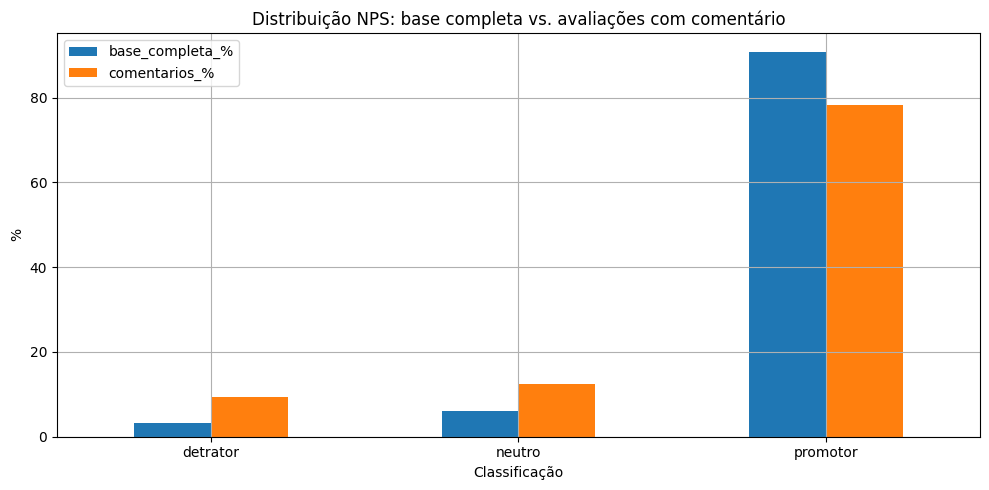

In [5]:
ordem_nps = ['detrator', 'neutro', 'promotor']

base_completa = (
    nps[nps['classificacao'].isin(ordem_nps)]
    .groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ordem_nps)
)
base_completa_pct = base_completa / base_completa.sum() * 100

base_comentarios = (
    nps[nps['tem_comentario'] & nps['classificacao'].isin(ordem_nps)]
    .groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ordem_nps)
)
base_comentarios_pct = base_comentarios / base_comentarios.sum() * 100

comparativo_dist = pd.DataFrame({
    'base_completa_qtd': base_completa,
    'base_completa_%': base_completa_pct,
    'comentarios_qtd': base_comentarios,
    'comentarios_%': base_comentarios_pct,
}).round(2)

display(comparativo_dist)

ax = comparativo_dist[['base_completa_%', 'comentarios_%']].plot(kind='bar')
ax.set_title('Distribuição NPS: base completa vs. avaliações com comentário')
ax.set_xlabel('Classificação')
ax.set_ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
loja_dist = (
    nps[nps['classificacao'].isin(ordem_nps)]
    .pivot_table(index='centronv2', columns='classificacao', values='qtd_clientes', aggfunc='sum', fill_value=0)
    .reindex(columns=ordem_nps, fill_value=0)
)
loja_dist['total'] = loja_dist.sum(axis=1)
for c in ordem_nps:
    loja_dist[f'pct_{c}'] = loja_dist[c] / loja_dist['total'] * 100

lojas_validas_dist = loja_dist[loja_dist['total'] >= 30].copy()
variacao_lojas = lojas_validas_dist[[f'pct_{c}' for c in ordem_nps]].describe().T.round(2)

display(variacao_lojas)

top_detratores = lojas_validas_dist.sort_values('pct_detrator', ascending=False).head(10)[['detrator', 'neutro', 'promotor', 'total', 'pct_detrator']]
display(top_detratores.round(2))

limite_desbalanceamento = 70
classe_mais_forte = base_comentarios_pct.idxmax()
pct_classe_mais_forte = base_comentarios_pct.max()
acao_balanceamento = 'usar pesos de classe ou amostragem estratificada no treino' if pct_classe_mais_forte >= limite_desbalanceamento else 'não aplicar balanceamento pesado de início; só manter split estratificado'

print(
    f"Conclusão acionável: entre as avaliações com comentário, a classe mais frequente é '{classe_mais_forte}' "
    f"com {pct_classe_mais_forte:.1f}% do volume. Com esse nível de concentração, a decisão é {acao_balanceamento}."
)

,count,mean,std,min,25%,50%,75%,max
classificacao,,,,,,,,
pct_detrator,228.0,3.29,1.17,1.05,2.50,3.15,3.91,7.44
pct_neutro,228.0,6.05,1.31,2.55,5.08,6.01,7.04,9.03
pct_promotor,228.0,90.66,2.31,83.70,89.11,90.84,92.26,96.07


classificacao,detrator,neutro,promotor,total,pct_detrator
centronv2,,,,,
L5007-KLABIN (0496),99,118,1114,1331,7.44
L5095-VILLA LOBOS (1380),110,114,1341,1565,7.03
L5017-LEOPOLDINA (0576),92,106,1185,1383,6.65
L5020-VILA MARIANA 2 (0779),114,168,1579,1861,6.13
L5082-VILA ANDRADE (1346),89,131,1266,1486,5.99
L5185-CLODOMIRO,82,102,1197,1381,5.94
L5063-SAO CAMILO (1311),61,61,918,1040,5.87
L5200-JUVENTUS,78,114,1191,1383,5.64
L5174-PERI PERI,94,121,1485,1700,5.53


Conclusão acionável: entre as avaliações com comentário, a classe mais frequente é 'promotor' com 78.3% do volume. Com esse nível de concentração, a decisão é usar pesos de classe ou amostragem estratificada no treino.


## 3.2 — Cobertura de comentários por loja

Aqui a pergunta é bem operacional: quais lojas têm volume suficiente para aparecer em um dashboard por loja sem virar ruído estatístico.

Lojas com pelo menos 1 comentário: 228
Lojas com menos de 30 comentários: 0
Lojas com menos de 50 comentários: 0

Top 10 lojas com mais comentários


,centronv2,comentarios,linhas_comentario,flag,regiao_im
191,L5230-LARGO DO MACHADO,1887,1886,REGULAR,RJ
187,L5223-CAMPO LIMPO,1580,1577,REGULAR,Capital
76,L5086-PORTAL DO MORUMBI (1352),1399,1396,REGULAR,Capital
159,L5184-PRACA VARNHAGEM,1364,1364,REGULAR,RJ
102,L5117-NOVA GRANADA,1203,1187,REGULAR,RMSP
16,L5019-ANGELICA (0684),1124,1123,REGULAR,Capital
133,L5152-ALTO DA BOA VISTA,1104,1102,TOCADORA,Capital
50,L5056-PENHA (1285),1073,1073,REGULAR,Capital
86,L5098-AUTONOMISTAS (1405),1016,1016,REGULAR,RMSP
138,L5158-LEBLON,997,996,REGULAR,RJ



Lojas com menor cobertura


,centronv2,comentarios,linhas_comentario,flag,regiao_im
214,L5262-URBANOVA,155,155,REGULAR,Interior
196,L5236-JACAREI VILLA BRANCA,201,198,REGULAR,Interior
227,L5290-SAO LOURENCO,223,223,REGULAR,Litoral
126,L5145-TAMBORE,242,242,REGULAR,RMSP
72,L5081-VILA OLIMPIA (1345),249,247,TOCADORA,Capital
118,L5136-RIB.PRETO ALTO DA BOA VISTA,261,261,REGULAR,Interior
174,L5205-GRANJA KM 26,272,272,REGULAR,RMSP
9,L5012-SOROCABA (0527),272,272,REGULAR,Interior
195,L5235-LOUVEIRA,275,275,TOCADORA,Interior
202,L5243-MONTE CASTELO,275,275,REGULAR,Interior


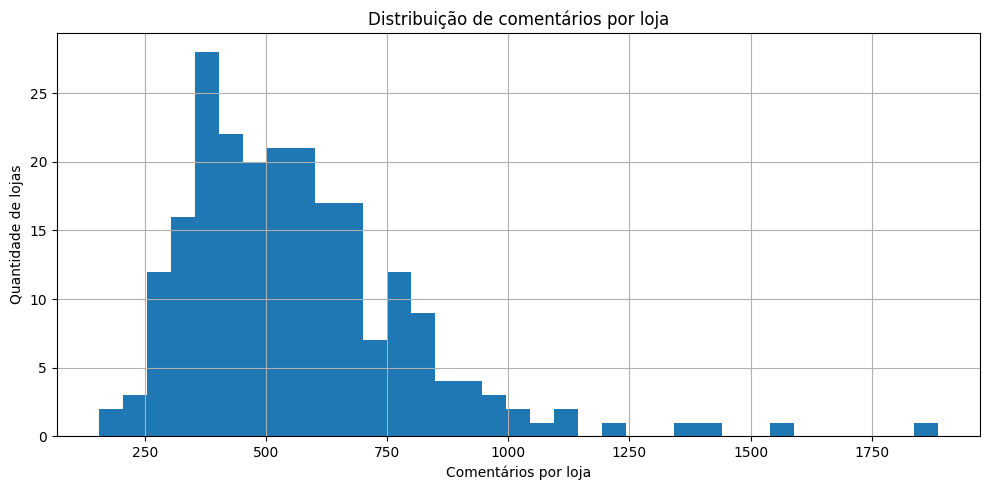

Conclusão acionável: 0 lojas têm menos de 30 comentários e 0 têm menos de 50. Para o dashboard, o corte recomendado neste notebook é 50 comentários por loja; abaixo disso, a loja entra apenas em visão agregada/regional.


In [7]:
comentarios_loja = (
    nps[nps['tem_comentario']]
    .groupby('centronv2', as_index=False)
    .agg(
        comentarios=('qtd_clientes', 'sum'),
        linhas_comentario=('comentario', 'size'),
        flag=('flag', lambda x: x.mode().iat[0] if not x.mode().empty else 'SEM_FLAG'),
        regiao_im=('regiao_im', lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
    )
    .sort_values('comentarios', ascending=False)
)

qtd_lojas = len(comentarios_loja)
lojas_menos_30 = (comentarios_loja['comentarios'] < 30).sum()
lojas_menos_50 = (comentarios_loja['comentarios'] < 50).sum()

print('Lojas com pelo menos 1 comentário:', qtd_lojas)
print('Lojas com menos de 30 comentários:', lojas_menos_30)
print('Lojas com menos de 50 comentários:', lojas_menos_50)

print('\nTop 10 lojas com mais comentários')
display(comentarios_loja.head(10))

print('\nLojas com menor cobertura')
display(comentarios_loja.tail(10).sort_values('comentarios'))

ax = comentarios_loja['comentarios'].plot(kind='hist', bins=35)
ax.set_title('Distribuição de comentários por loja')
ax.set_xlabel('Comentários por loja')
ax.set_ylabel('Quantidade de lojas')
plt.tight_layout()
plt.show()

threshold_dashboard = 50 if lojas_menos_50 / qtd_lojas <= 0.25 else 30
print(
    f"Conclusão acionável: {lojas_menos_30} lojas têm menos de 30 comentários e {lojas_menos_50} têm menos de 50. "
    f"Para o dashboard, o corte recomendado neste notebook é {threshold_dashboard} comentários por loja; abaixo disso, a loja entra apenas em visão agregada/regional."
)

## 3.3 — Características dos comentários

Comentários curtíssimos ajudam sentimento, mas quase não ajudam categoria. A ideia aqui é separar o que tem conteúdo de negócio do que é só avaliação genérica.

,num_palavras
count,128341.00
mean,16.04
std,20.36
min,1.00
5%,2.00
25%,5.00
50%,9.00
75%,20.00
95%,51.00
99%,95.00


% comentários com menos de 5 palavras: 23.83%
% comentários com mais de 100 palavras: 0.84%


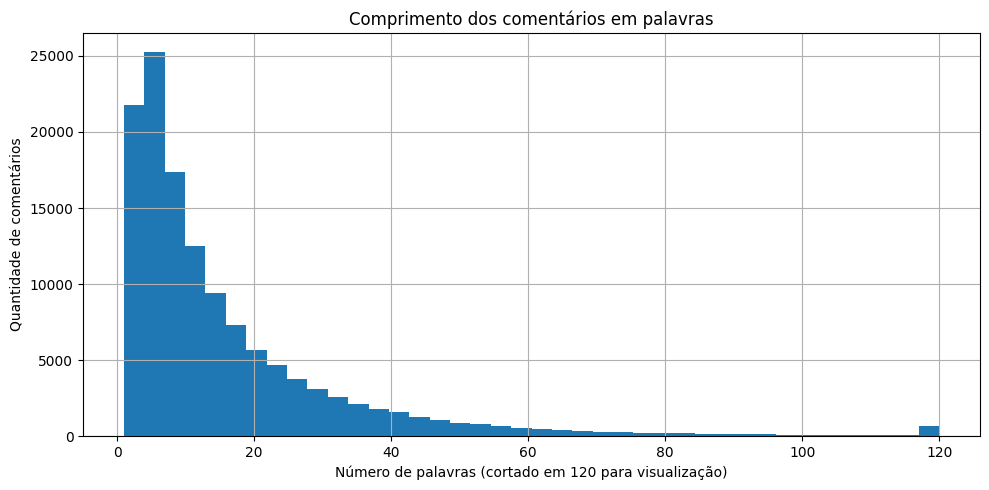

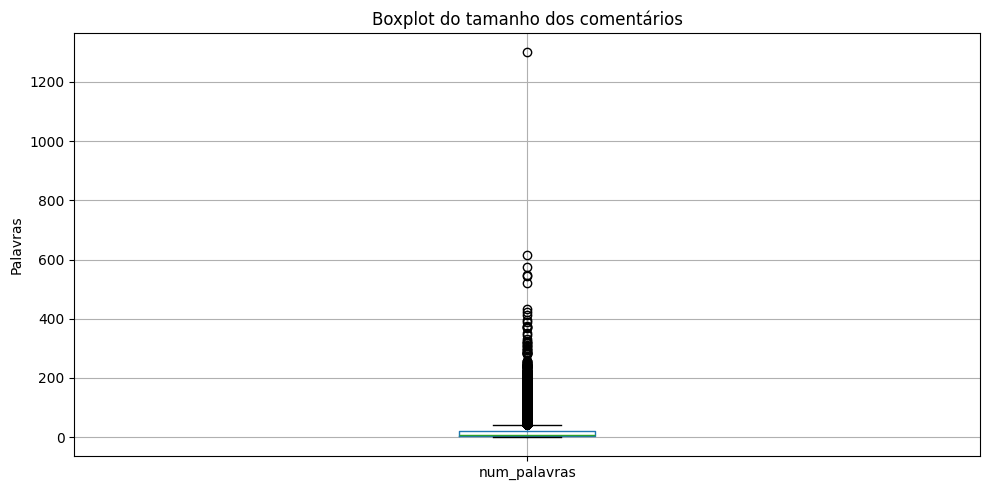

Conclusão acionável: 23.8% dos comentários têm menos de 5 palavras. A decisão é manter esses textos para sentimento, mas criar a flag texto_curto para não forçar categoria detalhada quando o comentário for genérico demais.


In [8]:
coment = nps[nps['tem_comentario']].copy()
coment['comentario_limpo_basico'] = coment['comentario'].str.replace(r'\s+', ' ', regex=True).str.strip()
coment['num_palavras'] = coment['comentario_limpo_basico'].str.split().str.len()
coment['num_caracteres'] = coment['comentario_limpo_basico'].str.len()

stats_texto = coment['num_palavras'].describe(percentiles=[.05, .25, .5, .75, .95, .99]).to_frame('num_palavras').round(2)
display(stats_texto)

pct_menos_5 = (coment['num_palavras'] < 5).mean() * 100
pct_mais_100 = (coment['num_palavras'] > 100).mean() * 100

print(f'% comentários com menos de 5 palavras: {pct_menos_5:.2f}%')
print(f'% comentários com mais de 100 palavras: {pct_mais_100:.2f}%')

ax = coment['num_palavras'].clip(upper=120).plot(kind='hist', bins=40)
ax.set_title('Comprimento dos comentários em palavras')
ax.set_xlabel('Número de palavras (cortado em 120 para visualização)')
ax.set_ylabel('Quantidade de comentários')
plt.tight_layout()
plt.show()

ax = coment.boxplot(column='num_palavras')
ax.set_title('Boxplot do tamanho dos comentários')
ax.set_ylabel('Palavras')
plt.tight_layout()
plt.show()

print(
    f"Conclusão acionável: {pct_menos_5:.1f}% dos comentários têm menos de 5 palavras. "
    "A decisão é manter esses textos para sentimento, mas criar a flag texto_curto para não forçar categoria detalhada quando o comentário for genérico demais."
)

## 3.4 — Qualidade e ruído dos dados

Faço uma limpeza leve para medir duplicidade, emojis, textos possivelmente fora do português e lixo evidente. A intenção aqui não é apagar dado ainda; é medir o tamanho do problema e documentar a decisão.

In [9]:
def limpar_para_comparacao(txt):
    txt = str(txt).lower().strip()
    txt = unicodedata.normalize('NFKD', txt).encode('ascii', 'ignore').decode('utf-8')
    txt = re.sub(r'http\S+|www\.\S+', ' ', txt)
    txt = re.sub(r'[^a-z0-9\s]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

emoji_regex = re.compile(
    '['
    '\U0001F300-\U0001FAFF'
    '\U00002700-\U000027BF'
    '\U00002600-\U000026FF'
    ']', flags=re.UNICODE
)

coment['texto_norm'] = coment['comentario'].map(limpar_para_comparacao)
coment['duplicata_exata'] = coment['comentario'].duplicated(keep=False)
coment['duplicata_normalizada'] = coment['texto_norm'].duplicated(keep=False)
coment['tem_emoji'] = coment['comentario'].str.contains(emoji_regex)
coment['so_numero_ou_sinal'] = coment['texto_norm'].str.fullmatch(r'[0-9\s]*').fillna(False)
coment['repeticao_caracter'] = coment['comentario'].str.contains(r'(.)\1{5,}', regex=True)
coment['possivel_lixo'] = coment['so_numero_ou_sinal'] | coment['repeticao_caracter'] | (coment['texto_norm'].str.len() <= 1)

# Heurística simples para idioma: conta presença de palavras funcionais PT.
# Para o objetivo da entrega, é suficiente para triagem; a versão de produção pode usar langdetect/fastText.
stop_pt_idioma = set('de da do das dos que para com nao não uma um por em no na os as e o a foi muito mais loja produto atendimento entrega bom boa ruim otimo ótimo pessimo péssimo'.split())
def provavel_portugues(txt):
    tokens = limpar_para_comparacao(txt).split()
    if len(tokens) < 3:
        return True  # curto demais para inferir
    hits = sum(t in stop_pt_idioma for t in tokens)
    tem_acento_pt = bool(re.search(r'[ãõáéíóúâêôç]', str(txt).lower()))
    return (hits >= 1) or tem_acento_pt

coment['provavel_portugues'] = coment['comentario'].map(provavel_portugues)
coment['possivel_nao_pt'] = ~coment['provavel_portugues']

qualidade = pd.DataFrame({
    'métrica': [
        'duplicatas exatas',
        'duplicatas normalizadas',
        'comentários com emoji',
        'possível não-PT (heurística)',
        'possível lixo/spam',
    ],
    'qtd': [
        coment['duplicata_exata'].sum(),
        coment['duplicata_normalizada'].sum(),
        coment['tem_emoji'].sum(),
        coment['possivel_nao_pt'].sum(),
        coment['possivel_lixo'].sum(),
    ],
})
qualidade['%'] = qualidade['qtd'] / len(coment) * 100

display(qualidade.round(2))

print('Comentários mais repetidos após normalização')
mais_repetidos = (
    coment[coment['texto_norm'].ne('')]
    .groupby('texto_norm')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='repeticoes')
)
display(mais_repetidos)

print('Amostra de comentários marcados como possível lixo/spam')
display(coment.loc[coment['possivel_lixo'], ['comentario', 'classificacao', 'centronv2']].head(10))

print(
    "Conclusão acionável: duplicatas normalizadas devem ser marcadas antes do treino para não inflar o padrão de frases genéricas. "
    "Emojis podem ser removidos ou convertidos, e textos muito curtos/lixo entram com flag própria em vez de serem apagados silenciosamente."
)

C:\Users\gabrielkondo-ieg\AppData\Local\Temp\ipykernel_15388\2473733166.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  coment['repeticao_caracter'] = coment['comentario'].str.contains(r'(.)\1{5,}', regex=True)


,métrica,qtd,%
0,duplicatas exatas,16693,13.01
1,duplicatas normalizadas,22453,17.49
2,comentários com emoji,537,0.42
3,possível não-PT (heurística),2736,2.13
4,possível lixo/spam,827,0.64


Comentários mais repetidos após normalização


,texto_norm,repeticoes
0,mais promocoes,842
1,tudo otimo,531
2,tudo perfeito,473
3,otimo atendimento,403
4,esta otimo,365
5,esta tudo otimo,304
6,muito bom,290
7,melhorar os precos,289
8,excelente,239
9,fazendo mais promocoes,239


Amostra de comentários marcados como possível lixo/spam


,comentario,classificacao,centronv2
186,Baixar os preços kkkkkkkkkkkkkkkk,promotor,L5001-RIBEIRAO PRETO (0217)
278,Nada para melhorar! Parabéns! Vocês pra mim são completos! Estou muito feliz em ter meu pãozinho francês que amo tod...,promotor,L5001-RIBEIRAO PRETO (0217)
470,Picanha ouro estava dura.........,neutro,L5001-RIBEIRAO PRETO (0217)
1250,Inaugurar um loja no meu bairro ????????,promotor,L5002-ALPHAVILLE (0290)
1309,"O atendimento foi perfeito, qualificado e com muita simpatia e atenção. \nParabéns!\nLoja organizada!\nProdutos exce...",promotor,L5002-ALPHAVILLE (0290)
1409,O site é muito ruimmmmmmmmmmmmmmmmm,neutro,L5002-ALPHAVILLE (0290)
1413,Mais combos de ofertas!????????,promotor,L5002-ALPHAVILLE (0290)
1420,Desculpa mais prescisa posicionar as partes do frango um em cada balcão e corredor separado que lay out é esse !!!!!...,detrator,L5002-ALPHAVILLE (0290)
2292,"Boa tarde, 2 pontos negativos sobre as panelinhas. Tem MUUUUUUITO sódio, comprei um baião de dois e infelizmente tiv...",promotor,L5002-ALPHAVILLE (0290)
2628,Melhorar o preço......,promotor,L5003-LINS (0340)


Conclusão acionável: duplicatas normalizadas devem ser marcadas antes do treino para não inflar o padrão de frases genéricas. Emojis podem ser removidos ou convertidos, e textos muito curtos/lixo entram com flag própria em vez de serem apagados silenciosamente.


## 3.5 — Análise temporal

Nesta parte junto NPS e transações por mês. A leitura principal é: volume, NPS médio e estabilidade. Quando a loja tem pouca avaliação, a variação mensal tende a ficar exagerada; por isso filtro lojas com volume mínimo antes de olhar volatilidade.

,mes_ano,avaliacoes,comentarios,promotores,detratores,nps,transacoes,taxa_avaliacao,taxa_comentario
0,2025-01-01,31013,8730,26831,1441,81.8689,1507247.0,0.0206,0.0058
1,2025-02-01,21670,5901,19481,768,86.3544,1451728.0,0.0149,0.0041
2,2025-03-01,25550,6906,22951,932,86.1800,1633161.0,0.0156,0.0042
3,2025-04-01,26824,7084,24279,942,87.0004,1641593.0,0.0163,0.0043
4,2025-05-01,29659,7760,27101,880,88.4082,1668353.0,0.0178,0.0047
5,2025-06-01,34552,8648,31869,867,89.7256,1494212.0,0.0231,0.0058
6,2025-07-01,26445,6524,24316,660,89.4536,1530011.0,0.0173,0.0043
7,2025-08-01,31213,7618,28758,785,89.6197,1679818.0,0.0186,0.0045
8,2025-09-01,30968,7822,28307,843,88.6851,1520788.0,0.0204,0.0051
9,2025-10-01,29785,7952,27110,883,88.0544,1572222.0,0.0189,0.0051


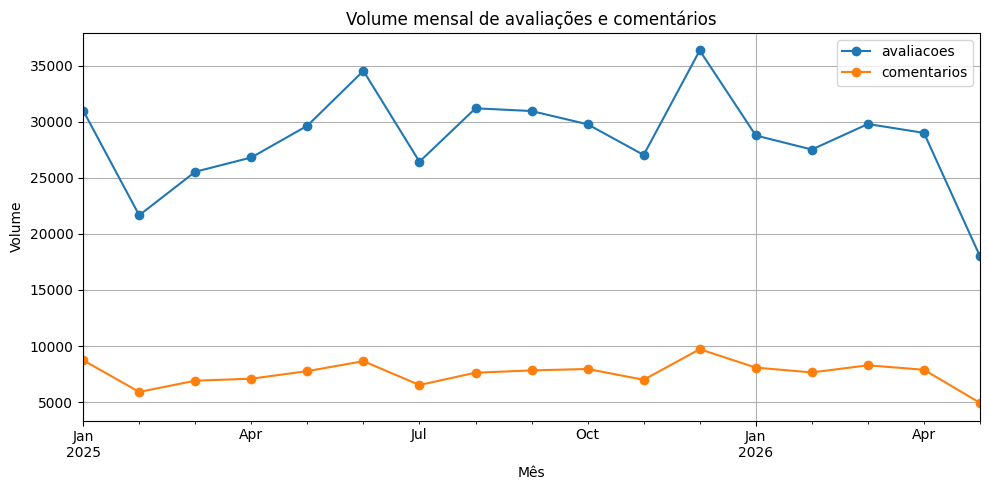

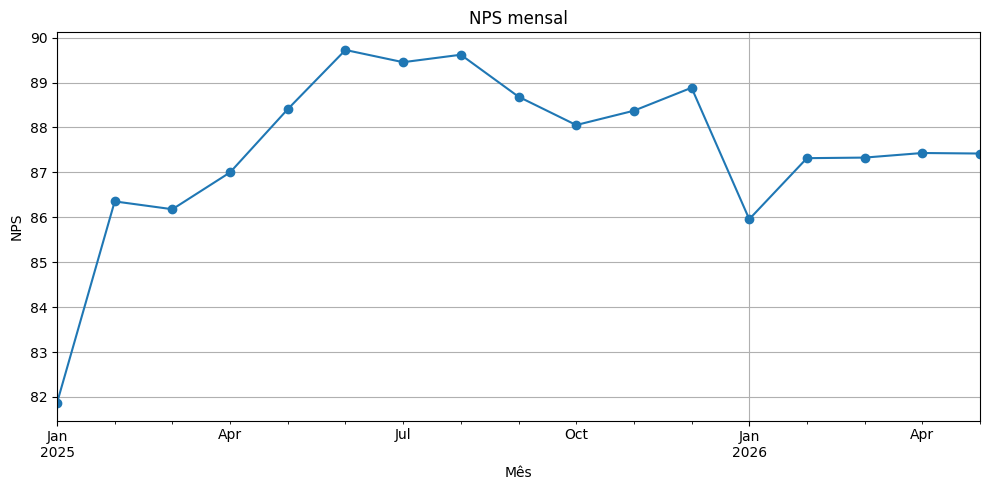

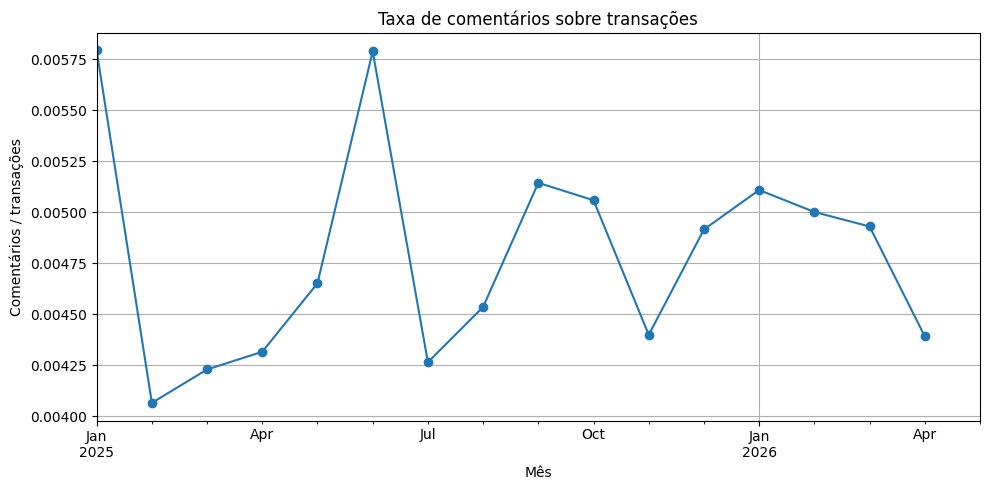

In [10]:
mensal = (
    nps[nps['classificacao'].isin(ordem_nps)]
    .groupby('mes_ano', as_index=False)
    .apply(lambda g: pd.Series({
        'avaliacoes': g['qtd_clientes'].sum(),
        'comentarios': g.loc[g['tem_comentario'], 'qtd_clientes'].sum(),
        'promotores': g.loc[g['classificacao'].eq('promotor'), 'qtd_clientes'].sum(),
        'detratores': g.loc[g['classificacao'].eq('detrator'), 'qtd_clientes'].sum(),
    }), include_groups=False)
)
mensal['nps'] = (mensal['promotores'] - mensal['detratores']) / mensal['avaliacoes'] * 100

trans_mensal = trans.groupby('mes_ano', as_index=False)['transacoes'].sum()
mensal = mensal.merge(trans_mensal, on='mes_ano', how='left')
mensal['taxa_avaliacao'] = mensal['avaliacoes'] / mensal['transacoes']
mensal['taxa_comentario'] = mensal['comentarios'] / mensal['transacoes']

display(mensal.round(4))

ax = mensal.plot(x='mes_ano', y=['avaliacoes', 'comentarios'], marker='o')
ax.set_title('Volume mensal de avaliações e comentários')
ax.set_xlabel('Mês')
ax.set_ylabel('Volume')
plt.tight_layout()
plt.show()

ax = mensal.plot(x='mes_ano', y='nps', marker='o', legend=False)
ax.set_title('NPS mensal')
ax.set_xlabel('Mês')
ax.set_ylabel('NPS')
plt.tight_layout()
plt.show()

ax = mensal.plot(x='mes_ano', y='taxa_comentario', marker='o', legend=False)
ax.set_title('Taxa de comentários sobre transações')
ax.set_xlabel('Mês')
ax.set_ylabel('Comentários / transações')
plt.tight_layout()
plt.show()

In [11]:
volatilidade = (
    loja_mes.dropna(subset=['nps'])
    .query('avaliacoes >= 30')
    .groupby('centronv2', as_index=False)
    .agg(
        meses=('mes_ano', 'nunique'),
        avaliacoes_media=('avaliacoes', 'mean'),
        nps_medio=('nps', 'mean'),
        nps_std=('nps', 'std'),
        flag=('flag', lambda x: x.mode().iat[0] if not x.mode().empty else 'SEM_FLAG'),
        regiao_im=('regiao_im', lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
    )
)
volatilidade = volatilidade[volatilidade['meses'] >= 4].sort_values('nps_std', ascending=False)

display(volatilidade.head(10).round(2))

queda_pico = mensal[['mes_ano', 'nps']].copy()
queda_pico['variacao_nps'] = queda_pico['nps'].diff()
display(queda_pico.sort_values('variacao_nps').head(3).round(2))
display(queda_pico.sort_values('variacao_nps', ascending=False).head(3).round(2))

print(
    "Conclusão acionável: a leitura temporal deve ser usada no dashboard para explicar picos e quedas, "
    "mas a sinalização de loja atípica precisa exigir volume mínimo mensal; caso contrário, loja com poucas avaliações parece instável sem necessariamente ser."
)

,centronv2,meses,avaliacoes_media,nps_medio,nps_std,flag,regiao_im
73,L5082-VILA ANDRADE (1346),17,87.41,77.82,11.04,REGULAR,Capital
17,L5020-VILA MARIANA 2 (0779),17,109.47,77.53,10.39,REGULAR,Capital
75,L5084-GUAIPA (1349),17,81.53,84.77,9.85,TOCADORA,Capital
160,L5185-CLODOMIRO,17,81.24,80.07,9.69,TOCADORA,Capital
175,L5206-CACHOEIRINHA,17,106.00,83.65,9.34,TOCADORA,Capital
6,L5007-KLABIN (0496),17,78.29,75.73,8.86,TOCADORA,Capital
150,L5174-PERI PERI,17,100.00,81.02,8.75,TOCADORA,Capital
57,L5063-SAO CAMILO (1311),16,63.62,81.34,8.68,REGULAR,RMSP
11,L5014-ROUXINOL (0567),17,79.59,80.05,8.65,TOCADORA,Capital
54,L5060-RIVIERA (1300),14,80.29,87.50,8.41,SEM_FLAG,Litoral


,mes_ano,nps,variacao_nps
12,2026-01-01,85.96,-2.93
8,2025-09-01,88.69,-0.93
9,2025-10-01,88.05,-0.63


,mes_ano,nps,variacao_nps
1,2025-02-01,86.35,4.49
4,2025-05-01,88.41,1.41
13,2026-02-01,87.32,1.36


Conclusão acionável: a leitura temporal deve ser usada no dashboard para explicar picos e quedas, mas a sinalização de loja atípica precisa exigir volume mínimo mensal; caso contrário, loja com poucas avaliações parece instável sem necessariamente ser.


## 3.6 — Análise léxica por classificação

A base recebida não tem a nota numérica 0–10; ela já vem com `classificacao`. Então, para aproximar o pedido de “notas 1–2 vs. 9–10”, uso **detrator** como proxy de baixa nota e **promotor** como proxy de alta nota.

C:\Users\gabrielkondo-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['otima', 'pessima'] not in stop_words.
  warnings.warn(
C:\Users\gabrielkondo-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['otima', 'pessima'] not in stop_words.
  warnings.warn(
C:\Users\gabrielkondo-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['otima', 'pessima'] not in stop_words.
  warnings.warn(
C:\Users\gabrielkondo-ieg\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_wor

Top palavras — detratores


,termo,freq
0,nao,9937
1,estava,2615
2,comprei,2397
3,eu,2104
4,pedido,1828
5,qualidade,1766
6,me,1688
7,picanha,1507
8,so,1283
9,entrega,1257


Top palavras — promotores


,termo,freq
0,nao,20522
1,precos,9231
2,promocoes,7059
3,eu,5619
4,excelente,5369
5,qualidade,5271
6,parabens,5249
7,sao,5233
8,melhorar,5102
9,so,4881


Top bigramas — detratores


,termo,freq
0,contra file,366
1,nao recebi,352
2,comprei picanha,275
3,nao estava,263
4,estava dura,237
5,eu nao,232
6,pedido nao,221
7,nao sei,198
8,nao me,189
9,nao recomendo,177


Top bigramas — promotores


,termo,freq
0,nao encontrei,1737
1,pra mim,1148
2,melhorar precos,928
3,fui atendida,897
4,nao tenho,857
5,estao parabens,845
6,fazer promocoes,712
7,me atendeu,702
8,fui atendido,693
9,fazendo promocoes,691


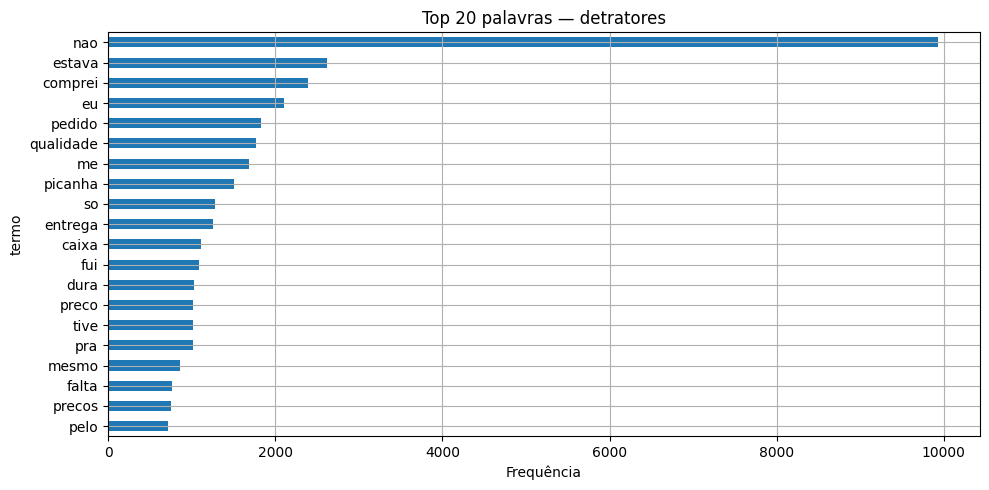

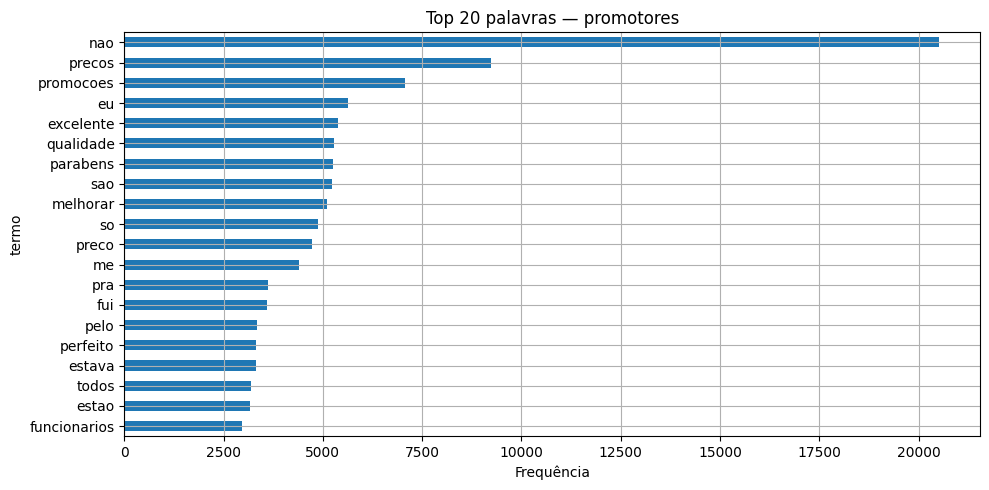

Sobreposição no top 20 de palavras: 11
['estava', 'eu', 'fui', 'me', 'nao', 'pelo', 'pra', 'preco', 'precos', 'qualidade', 'so']
Conclusão acionável: há 11 termos em comum entre os top 20 de detratores e promotores. Se a sobreposição for alta, o modelo de sentimento deve depender mais de contexto/frases do que de palavras soltas; para categorias, bigramas tendem a ser mais informativos.


In [12]:
try:
    from sklearn.feature_extraction.text import CountVectorizer
    sklearn_ok = True
except Exception as e:
    sklearn_ok = False
    print('sklearn não disponível:', e)

stopwords_pt = set("""
a o os as um uma uns umas de da do das dos em no na nos nas por para com sem sobre entre ate até e ou mas que se ao aos aonde onde como quando porque pois seu sua seus suas meu minha meus minhas nosso nossa nossos nossas esse essa esses essas este esta estes estas isso isto aquele aquela aqueles aquelas foi foram era eram ser ter tem tinha tinham ha há ja já muito muita muitos muitas pouco pouca poucos poucas mais menos bem mal bom boa bons boas ruim ruins otimo ótima ótimo otimos ótimos pessimo péssima péssimo pessimos péssimos loja lojas produto produtos comprar compra cliente clientes swift mercado mercados carne carnes atendimento atendente dia dias vez vezes tudo nada sempre""".split())
# Mantém negação fora da lista, porque ela muda o sentido.
for neg in ['nao', 'não', 'nunca', 'jamais']:
    stopwords_pt.discard(neg)


def top_termos(textos, ngram_range=(1, 1), top_n=20, min_df=5):
    textos = pd.Series(textos).dropna().astype(str)
    if len(textos) == 0:
        return pd.DataFrame(columns=['termo', 'freq'])
    if sklearn_ok:
        vec = CountVectorizer(
            lowercase=True,
            strip_accents='unicode',
            stop_words=list(stopwords_pt),
            ngram_range=ngram_range,
            min_df=min_df,
            token_pattern=r'(?u)\b[a-zA-ZÀ-ÿ]{2,}\b'
        )
        X = vec.fit_transform(textos)
        freqs = np.asarray(X.sum(axis=0)).ravel()
        termos = np.array(vec.get_feature_names_out())
        ordem = freqs.argsort()[::-1][:top_n]
        return pd.DataFrame({'termo': termos[ordem], 'freq': freqs[ordem]})
    else:
        tokens = []
        for txt in textos:
            norm = limpar_para_comparacao(txt)
            toks = [t for t in norm.split() if len(t) >= 2 and t not in stopwords_pt]
            tokens.extend(toks)
        return pd.DataFrame(Counter(tokens).most_common(top_n), columns=['termo', 'freq'])

coment_det = coment[coment['classificacao'].eq('detrator')]['comentario']
coment_pro = coment[coment['classificacao'].eq('promotor')]['comentario']

terms_det_uni = top_termos(coment_det, (1, 1), 20)
terms_pro_uni = top_termos(coment_pro, (1, 1), 20)
terms_det_bi = top_termos(coment_det, (2, 2), 20)
terms_pro_bi = top_termos(coment_pro, (2, 2), 20)

print('Top palavras — detratores')
display(terms_det_uni)
print('Top palavras — promotores')
display(terms_pro_uni)
print('Top bigramas — detratores')
display(terms_det_bi)
print('Top bigramas — promotores')
display(terms_pro_bi)

fig, ax = plt.subplots(figsize=(10, 5))
terms_det_uni.sort_values('freq').plot(x='termo', y='freq', kind='barh', ax=ax, legend=False)
ax.set_title('Top 20 palavras — detratores')
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
terms_pro_uni.sort_values('freq').plot(x='termo', y='freq', kind='barh', ax=ax, legend=False)
ax.set_title('Top 20 palavras — promotores')
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.show()

sobreposicao = sorted(set(terms_det_uni['termo']) & set(terms_pro_uni['termo']))
print('Sobreposição no top 20 de palavras:', len(sobreposicao))
print(sobreposicao)

print(
    f"Conclusão acionável: há {len(sobreposicao)} termos em comum entre os top 20 de detratores e promotores. "
    "Se a sobreposição for alta, o modelo de sentimento deve depender mais de contexto/frases do que de palavras soltas; para categorias, bigramas tendem a ser mais informativos."
)

## 4. Recorte por Flag e região

,flag,avaliacoes,comentarios,promotores,detratores,lojas,nps,%comentario
0,REGULAR,381057,98673,347796,11137,169,88.35,25.89
1,SEM_FLAG,1124,402,1021,45,1,86.83,35.77
2,TOCADORA,102074,29375,90800,4268,58,84.77,28.78


,regiao_im,flag,avaliacoes,comentarios,promotores,detratores,lojas,nps,%comentario
0,Capital,REGULAR,116019,30947,104694,3949,46,86.83,26.67
1,Capital,TOCADORA,79116,23645,70026,3497,45,84.09,29.89
2,DF,REGULAR,13321,3456,12052,371,7,87.69,25.94
3,GO,REGULAR,1621,395,1457,56,1,86.43,24.37
4,Interior,REGULAR,98191,22207,90848,2293,51,90.19,22.62
5,Interior,TOCADORA,10931,2801,9936,354,6,87.66,25.62
6,Litoral,REGULAR,40459,11126,37234,1043,16,89.45,27.50
7,Litoral,SEM_FLAG,1124,402,1021,45,1,86.83,35.77
8,Litoral,TOCADORA,1364,319,1249,31,1,89.30,23.39
9,RJ,REGULAR,26944,7904,24554,776,8,88.25,29.33


flag,REGULAR,SEM_FLAG,TOCADORA
regiao_im,,,
Capital,86.83,NaN,84.09
DF,87.69,NaN,NaN
GO,86.43,NaN,NaN
Interior,90.19,NaN,87.66
Litoral,89.45,86.83,89.30
RJ,88.25,NaN,NaN
RMSP,87.94,NaN,86.31


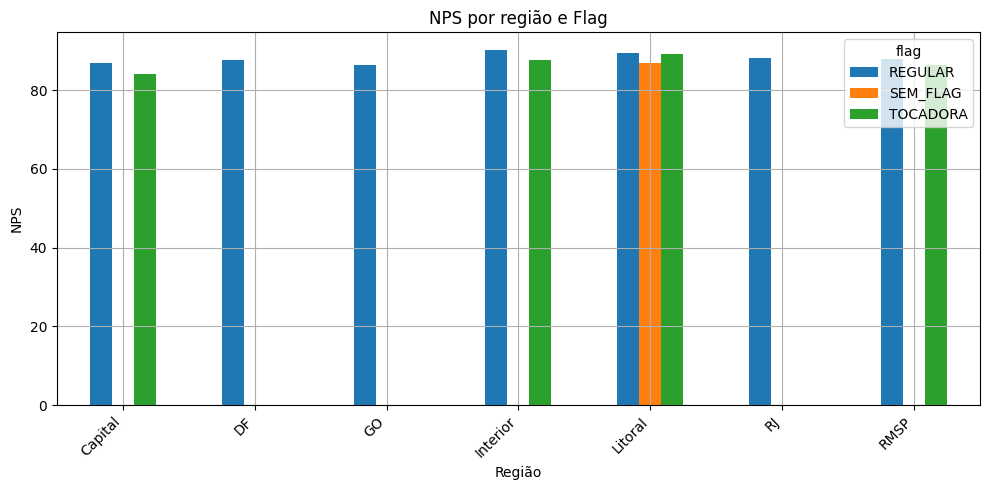

Conclusão acionável: a comparação TOCADORA vs REGULAR deve ser feita dentro da mesma região ou com ajuste regional. O número bruto por flag é útil como leitura inicial, mas não deve ser usado sozinho para validar a hipótese.


In [13]:
def resumo_nps_por(grupo_cols):
    tmp = (
        nps[nps['classificacao'].isin(ordem_nps)]
        .groupby(grupo_cols, dropna=False)
        .apply(lambda g: pd.Series({
            'avaliacoes': g['qtd_clientes'].sum(),
            'comentarios': g.loc[g['tem_comentario'], 'qtd_clientes'].sum(),
            'promotores': g.loc[g['classificacao'].eq('promotor'), 'qtd_clientes'].sum(),
            'detratores': g.loc[g['classificacao'].eq('detrator'), 'qtd_clientes'].sum(),
            'lojas': g['centronv2'].nunique(),
        }), include_groups=False)
        .reset_index()
    )
    tmp['nps'] = (tmp['promotores'] - tmp['detratores']) / tmp['avaliacoes'] * 100
    tmp['%comentario'] = tmp['comentarios'] / tmp['avaliacoes'] * 100
    return tmp.sort_values(grupo_cols).round(2)

resumo_flag = resumo_nps_por(['flag'])
resumo_regiao_flag = resumo_nps_por(['regiao_im', 'flag'])

display(resumo_flag)
display(resumo_regiao_flag.sort_values(['regiao_im', 'flag']))

pivot_flag_regiao = resumo_regiao_flag.pivot(index='regiao_im', columns='flag', values='nps')
display(pivot_flag_regiao.round(2))

ax = pivot_flag_regiao.plot(kind='bar')
ax.set_title('NPS por região e Flag')
ax.set_xlabel('Região')
ax.set_ylabel('NPS')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(
    "Conclusão acionável: a comparação TOCADORA vs REGULAR deve ser feita dentro da mesma região ou com ajuste regional. "
    "O número bruto por flag é útil como leitura inicial, mas não deve ser usado sozinho para validar a hipótese."
)

## 5. Dataset base para pré-processamento


In [14]:
dataset_pre = coment[[
    'mes_ano', 'data_avaliacao', 'centronv2', 'regiao_im', 'municipio', 'uf',
    'flag', 'classificacao', 'qtd_clientes', 'comentario',
    'comentario_limpo_basico', 'num_palavras', 'num_caracteres',
    'duplicata_exata', 'duplicata_normalizada', 'tem_emoji', 'possivel_nao_pt', 'possivel_lixo'
]].copy()

dataset_pre['flag_curto'] = dataset_pre['num_palavras'] < 5

display(dataset_pre.head())
print(dataset_pre.shape)

saida_csv = PROCESSED_DIR / 'dataset_nps_preprocessamento_base.csv'
saida_csv.parent.mkdir(parents=True, exist_ok=True)

dataset_pre.to_csv(saida_csv, index=False, encoding='utf-8-sig')

print('Arquivo gerado:', saida_csv)

,mes_ano,data_avaliacao,centronv2,regiao_im,municipio,uf,flag,classificacao,qtd_clientes,comentario,comentario_limpo_basico,num_palavras,num_caracteres,duplicata_exata,duplicata_normalizada,tem_emoji,possivel_nao_pt,possivel_lixo,flag_curto
1,2025-01-01,2025-01-02,L5001-RIBEIRAO PRETO (0217),Interior,RIBEIRÃO PRETO,SP,REGULAR,neutro,1,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,Bastante falta. De produto. Talvez pela data. Mas não tinha muita coisa. Principalmente bovino,14,94,False,False,False,False,False,False
2,2025-01-01,2025-01-02,L5001-RIBEIRAO PRETO (0217),Interior,RIBEIRÃO PRETO,SP,REGULAR,neutro,1,"Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes","Estrutura excelente, mas, os peços deveriam ser melhores ou equivalentes aos mercados de carnes",14,95,False,False,False,False,False,False
3,2025-01-01,2025-01-02,L5001-RIBEIRAO PRETO (0217),Interior,RIBEIRÃO PRETO,SP,REGULAR,neutro,1,Melhorar o preço!,Melhorar o preço!,3,17,True,True,False,False,False,True
6,2025-01-01,2025-01-02,L5001-RIBEIRAO PRETO (0217),Interior,RIBEIRÃO PRETO,SP,REGULAR,promotor,1,Alguns produtos com porções menores.,Alguns produtos com porções menores.,5,36,False,False,False,False,False,False
7,2025-01-01,2025-01-02,L5001-RIBEIRAO PRETO (0217),Interior,RIBEIRÃO PRETO,SP,REGULAR,promotor,1,Estão de parabéns,Estão de parabéns,3,17,True,True,False,False,False,True


(128341, 19)
Arquivo gerado: c:\Users\gabrielkondo-ieg\OneDrive - Instituto Germinare\Área de Trabalho\TECH\3ano\ciencia_de_dados\nps-swift\data\processed\dataset_nps_preprocessamento_base.csv
